In [5]:
import sys
sys.path.append("..")
import importlib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import src.config as config
import src.data as data
import src.backtest as backtest
importlib.reload(data)
importlib.reload(backtest)

hist = data.load_history("2007-01-01", config.SNAPSHOT_DATE)
print(f"{len(hist)} jours de bourse, du {hist.index[0].date()} au {hist.index[-1].date()}")
hist.tail()

4968 jours de bourse, du 2007-01-03 au 2026-10-05


,SPY,VIX,IRX
Date,,,
2026-09-29,764.200012,16.040001,4.065
2026-09-30,762.630005,16.340000,4.030
2026-10-01,763.989990,16.389999,3.982
2026-10-02,769.640015,15.310000,3.993
2026-10-05,774.830017,15.520000,4.018


In [6]:
bt = backtest.monthly_vol_selling(hist)
print(f"{len(bt)} mois de vente de volatilité\n")

print(f"Vol implicite moyenne (VIX)            : {bt['vix'].mean():.1%}")
print(f"Vol réalisée moyenne (mois suivant)    : {bt['realized'].mean():.1%}")
print(f"Mois où l'implicite > la réalisée      : {(bt['vix'] > bt['realized']).mean():.0%}\n")

for col, name in [("varswap_pnl", "Variance swap vendu (points de vol)"),
                  ("straddle_pnl_pct", "Straddle couvert vendu (% du spot)")]:
    x = bt[col]
    print(f"{name}")
    print(f"   moyenne {x.mean():+.2f} | médiane {x.median():+.2f} | mois gagnants {(x > 0).mean():.0%} | "
          f"pire mois {x.min():+.2f} ({x.idxmin().date()})")

print("\nLes 5 pires mois pour le vendeur de variance :")
print(bt.nsmallest(5, "varswap_pnl")[["vix", "realized", "varswap_pnl", "straddle_pnl_pct"]].round(3))

236 mois de vente de volatilité

Vol implicite moyenne (VIX)            : 20.0%
Vol réalisée moyenne (mois suivant)    : 16.1%
Mois où l'implicite > la réalisée      : 83%

Variance swap vendu (points de vol)
   moyenne +2.06 | médiane +3.95 | mois gagnants 83% | pire mois -118.70 (2020-02-11)
Straddle couvert vendu (% du spot)
   moyenne +0.84 | médiane +0.97 | mois gagnants 82% | pire mois -4.96 (2025-03-18)

Les 5 pires mois pour le vendeur de variance :
              vix  realized  varswap_pnl  straddle_pnl_pct
date                                                      
2020-02-11  0.152     0.619     -118.702            -1.100
2008-10-02  0.453     0.901      -67.009            -4.259
2008-09-03  0.214     0.498      -47.045            -4.423
2025-03-18  0.217     0.495      -45.692            -4.965
2015-08-07  0.134     0.309      -28.844            -1.227


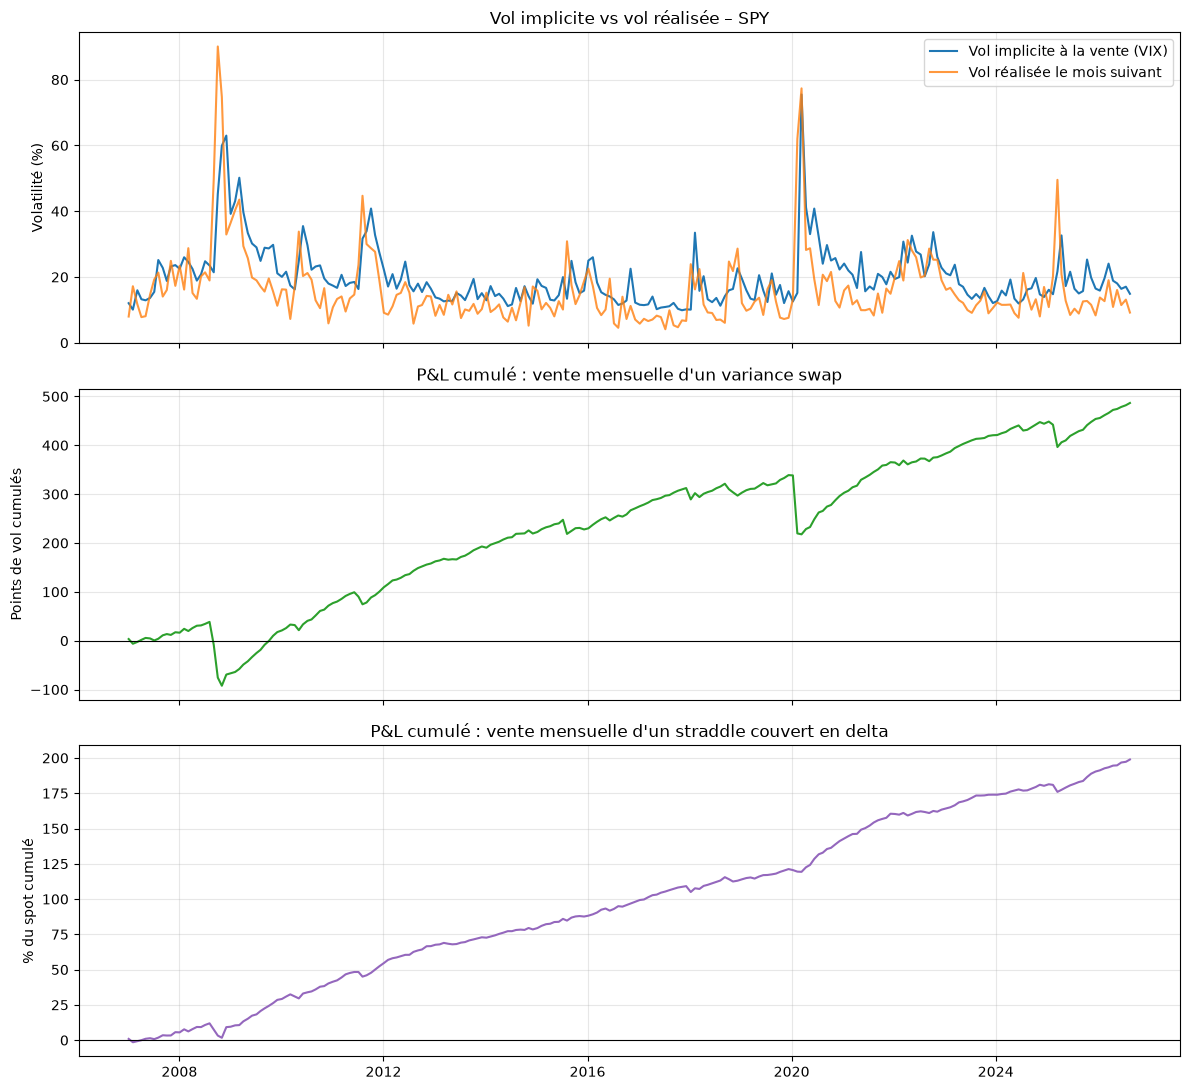

In [7]:
fig, axes = plt.subplots(3, 1, figsize=(12, 11), sharex=True)

axes[0].plot(bt.index, bt["vix"] * 100, label="Vol implicite à la vente (VIX)")
axes[0].plot(bt.index, bt["realized"] * 100, label="Vol réalisée le mois suivant", alpha=0.8)
axes[0].set_ylabel("Volatilité (%)")
axes[0].set_title("Vol implicite vs vol réalisée – SPY")

axes[1].plot(bt.index, bt["varswap_pnl"].cumsum(), color="tab:green")
axes[1].set_ylabel("Points de vol cumulés")
axes[1].set_title("P&L cumulé : vente mensuelle d'un variance swap")

axes[2].plot(bt.index, bt["straddle_pnl_pct"].cumsum(), color="tab:purple")
axes[2].set_ylabel("% du spot cumulé")
axes[2].set_title("P&L cumulé : vente mensuelle d'un straddle couvert en delta")

for ax in axes:
    ax.axhline(0, color="black", linewidth=0.8)
    ax.grid(alpha=0.3)
axes[0].legend()

fig.tight_layout()
fig.savefig("../figures/backtest_vol_selling.png", dpi=150, bbox_inches="tight")
plt.show()

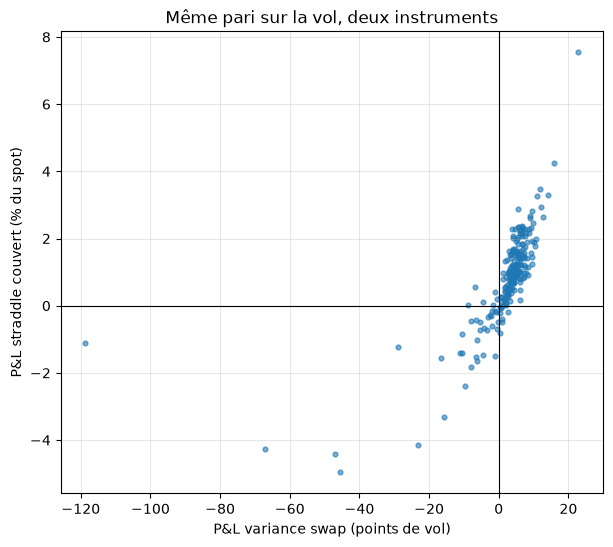

Corrélation : 0.67


In [8]:
fig, ax = plt.subplots(figsize=(7, 6))
ax.scatter(bt["varswap_pnl"], bt["straddle_pnl_pct"], s=12, alpha=0.6)
ax.axhline(0, color="black", linewidth=0.8)
ax.axvline(0, color="black", linewidth=0.8)
ax.set_xlabel("P&L variance swap (points de vol)")
ax.set_ylabel("P&L straddle couvert (% du spot)")
ax.set_title("Même pari sur la vol, deux instruments")
ax.grid(alpha=0.3)
fig.savefig("../figures/backtest_varswap_vs_straddle.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"Corrélation : {bt['varswap_pnl'].corr(bt['straddle_pnl_pct']):.2f}")

In [9]:
importlib.reload(backtest)
rows = []
for shift in [0.0, 0.01, 0.02, 0.027, 0.03]:
    b = backtest.monthly_vol_selling(hist, straddle_vol_shift=shift)
    x = b["straddle_pnl_pct"]
    rows.append({"vol de vente": f"VIX − {shift * 100:.1f} pts",
                 "P&L moyen (% spot/mois)": x.mean(),
                 "mois gagnants": (x > 0).mean(),
                 "Sharpe annualisé": x.mean() / x.std() * np.sqrt(12)})
print(pd.DataFrame(rows).round(3).to_string(index=False))

 vol de vente  P&L moyen (% spot/mois)  mois gagnants  Sharpe annualisé
VIX − 0.0 pts                    0.843          0.822             2.184
VIX − 1.0 pts                    0.613          0.758             1.601
VIX − 2.0 pts                    0.384          0.720             1.005
VIX − 2.7 pts                    0.223          0.682             0.583
VIX − 3.0 pts                    0.153          0.653             0.402
